In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ConstantKernel as C
import warnings

warnings.filterwarnings("ignore")


def run_single_output_gp_sklearn(
    data_path,
    target_output_name=None,
    target_output_idx=0,
    custom_lengthscales=None,
    kernel_type="matern",
    nu=2.5,
    n_restarts=10
):
    """Train 6D → 1D GP with sklearn"""
    
    print("=" * 70)
    print("1. LOADING DATA FOR 6D → 1D GP (SKLEARN)")
    print("=" * 70)

    data = np.load(data_path)

    X_raw = data["X"]
    Y_raw = data["Y"]
    Y_std_raw = data["Y_std"]

    param_names = list(data["param_names"])
    output_names = list(data["output_names"])

    print("Input parameters:", param_names)
    print("\nAvailable outputs:")
    for i, name in enumerate(output_names):
        print(f"  {i}: {name}")

    if target_output_name is not None:
        target_output_idx = output_names.index(target_output_name)

    target_name = output_names[target_output_idx]
    print(f"\n✅ Selected target: {target_name}")

    X = X_raw
    y = Y_raw[:, target_output_idx]
    y_std = Y_std_raw[:, target_output_idx]

    valid_mask = ~np.isnan(y)
    X = X[valid_mask]
    y = y[valid_mask]
    y_std = y_std[valid_mask]

    print(f"\nDataset shape: X={X.shape}, y={y.shape}")

    # Train/test split
    X_train, X_test, y_train, y_test, y_std_train, y_std_test = train_test_split(
        X, y, y_std, test_size=0.2, random_state=42
    )

    # Standardize
    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
    y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

    y_std_train_scaled = y_std_train / scaler_y.scale_[0]
    y_var_train_scaled = y_std_train_scaled ** 2
    alpha_tr_scaled = np.clip(y_var_train_scaled, 1e-6, None)

    print(f"\nNoise variance range (scaled): [{alpha_tr_scaled.min():.6f}, {alpha_tr_scaled.max():.6f}]")

    # Kernel
    print("\n" + "=" * 70)
    print("2. BUILDING GP KERNEL")
    print("=" * 70)

    if custom_lengthscales is None:
        custom_lengthscales = [1.0] * 6

    print(f"Initial lengthscales: {custom_lengthscales}")

    if kernel_type == "matern":
        base_kernel = Matern(
            length_scale=custom_lengthscales,
            length_scale_bounds=[(1e-3, 5), (1e-3, 15), (1e-3, 15),(1e-3, 15), (1e-3, 15), (1e-3, 15)],
            nu=nu
        )
    elif kernel_type == "rbf":
        base_kernel = RBF(
            length_scale=custom_lengthscales,
            length_scale_bounds=[(1e-3, 1e3)] * 6
        )

    kernel = C(1.0, (1e-3, 1e3)) * base_kernel

    # Train
    print("\n" + "=" * 70)
    print("3. TRAINING GP")
    print("=" * 70)

    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=alpha_tr_scaled,
        n_restarts_optimizer=n_restarts,
        normalize_y=False,
        random_state=42
    )

    gp.fit(X_train_scaled, y_train_scaled)

    print("\n✅ Training complete!")
    print(f"Final kernel: {gp.kernel_}")

    learned_lengthscales = gp.kernel_.k2.length_scale

    print("\n" + "=" * 70)
    print("📏 LEARNED LENGTHSCALES")
    print("=" * 70)

    for i, name in enumerate(param_names):
        print(f"  {name:<15} : {learned_lengthscales[i]:.4f}")

    # ========================================================================
    # PREDICT ON ENTIRE DATASET (TRAIN + TEST)
    # ========================================================================
    print("\n" + "=" * 70)
    print("4. PREDICTING ON ENTIRE DATASET")
    print("=" * 70)

    # Combine train and test
    X_full = np.vstack([X_train, X_test])
    y_full = np.hstack([y_train, y_test])
    y_std_full = np.hstack([y_std_train, y_std_test])
    
    # Track which are test points
    is_test = np.zeros(len(X_full), dtype=bool)
    is_test[len(X_train):] = True

    X_full_scaled = scaler_X.transform(X_full)

    y_pred_full_scaled, y_std_pred_full_scaled = gp.predict(X_full_scaled, return_std=True)

    y_pred_full = scaler_y.inverse_transform(y_pred_full_scaled.reshape(-1, 1)).ravel()
    y_std_pred_full = y_std_pred_full_scaled * scaler_y.scale_[0]

    # Metrics on test set only
    y_pred_test = y_pred_full[is_test]
    y_test_actual = y_full[is_test]

    r2 = r2_score(y_test_actual, y_pred_test)
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_test))

    print(f"\nTarget output : {target_name}")
    print(f"R² score (test) : {r2:.4f}")
    print(f"RMSE (test)     : {rmse:.4f}")

    return {
        "model":            gp,
        "scaler_X":         scaler_X,
        "scaler_y":         scaler_y,
        "param_names":      param_names,
        "target_name":      target_name,
        "X_train":          X_train,
        "X_test":           X_test,
        "X_full":           X_full,
        "y_train":          y_train,
        "y_test":           y_test,
        "y_full":           y_full,
        "y_std_full":       y_std_full,
        "y_pred_full":      y_pred_full,
        "y_std_pred_full":  y_std_pred_full,
        "is_test":          is_test,
        "learned_lengthscales": learned_lengthscales,
        "r2":               r2,
        "rmse":             rmse,
        # ... all your existing keys ...
        "target_output_idx": target_output_idx,  # Add this
        "custom_lengthscales": custom_lengthscales,  # Add this
        "kernel_type": kernel_type,  # Add this  
        "nu": nu,  # Add this
        "n_restarts": n_restarts,  # Add this
}
    


In [ ]:
def analyze_single_output_gp_sklearn(results):
    """Enhanced analysis with full dataset visualization"""

    gp = results["model"]
    scaler_X = results["scaler_X"]
    scaler_y = results["scaler_y"]

    param_names = results["param_names"]
    target_name = results["target_name"]

    X_train = results["X_train"]
    X_test = results["X_test"]
    X_full = results["X_full"]
    
    y_train = results["y_train"]
    y_test = results["y_test"]
    y_full = results["y_full"]
    y_std_full = results["y_std_full"]
    
    y_pred_full = results["y_pred_full"]
    y_std_pred_full = results["y_std_pred_full"]
    
    is_test = results["is_test"]
    lengthscales = results["learned_lengthscales"]

    print("\n" + "=" * 70)
    print("5. ENHANCED ANALYSIS")
    print("=" * 70)

    # ========================================================================
    # 1. PARITY PLOT WITH UNCERTAINTY (FULL DATASET)
    # ========================================================================
    fig, ax = plt.subplots(figsize=(9, 9))

    min_val = min(np.min(y_full), np.min(y_pred_full))
    max_val = max(np.max(y_full), np.max(y_pred_full))

    # Perfect prediction line
    ax.plot([min_val, max_val], [min_val, max_val], "k--", lw=2.5, label="Perfect prediction", zorder=1)

    # Training points (blue with low alpha)
    ax.scatter(
        y_full[~is_test], 
        y_pred_full[~is_test],
        c='royalblue',
        alpha=0.4,
        s=60,
        edgecolor='k',
        linewidth=0.5,
        label=f'Training points (n={np.sum(~is_test)})',
        zorder=2
    )

    # Test points (RED - highly visible)
    ax.scatter(
        y_full[is_test],
        y_pred_full[is_test],
        c='crimson',
        alpha=0.85,
        s=100,
        edgecolor='darkred',
        linewidth=1.5,
        marker='s',
        label=f'Test points (n={np.sum(is_test)})',
        zorder=3
    )

    # Add error bars for test points showing GP uncertainty
    ax.errorbar(
        y_full[is_test],
        y_pred_full[is_test],
        yerr=2 * y_std_pred_full[is_test],
        fmt='none',
        ecolor='red',
        alpha=0.3,
        capsize=3,
        zorder=2
    )

    ax.set_xlabel("True CAFM Output", fontsize=14, fontweight='bold')
    ax.set_ylabel("GP Predicted Output", fontsize=14, fontweight='bold')
    ax.set_title(f"Parity Plot: {target_name}\n(Red = Test Points with GP Uncertainty)", 
                 fontsize=15, fontweight="bold")

    r2 = results["r2"]
    rmse = results["rmse"]

    ax.text(
        0.05, 0.92,
        f"Test Set Metrics:\n$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}",
        transform=ax.transAxes,
        fontsize=12,
        bbox=dict(facecolor="white", alpha=0.9, edgecolor="k", linewidth=2)
    )

    ax.legend(loc='lower right', fontsize=11, frameon=True, shadow=True)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"full_parity_{target_name}.png", dpi=300)
    plt.show()

    # ========================================================================
    # 2. UNCERTAINTY CONFIDENCE MAP
    # ========================================================================
    fig, ax = plt.subplots(figsize=(10, 6))

    # Sort by predicted value for visualization
    sort_idx = np.argsort(y_pred_full)
    
    y_pred_sorted = y_pred_full[sort_idx]
    y_true_sorted = y_full[sort_idx]
    y_std_sorted = y_std_pred_full[sort_idx]
    is_test_sorted = is_test[sort_idx]

    x_axis = np.arange(len(y_pred_sorted))

    # Plot GP prediction band
    ax.fill_between(
        x_axis,
        y_pred_sorted - 2 * y_std_sorted,
        y_pred_sorted + 2 * y_std_sorted,
        color='lightblue',
        alpha=0.5,
        label=r'GP $\pm 2\sigma$ (95% confidence)'
    )

    ax.plot(x_axis, y_pred_sorted, 'b-', lw=2, label='GP Mean Prediction')

    # Training points
    train_mask = ~is_test_sorted
    ax.scatter(
        x_axis[train_mask],
        y_true_sorted[train_mask],
        c='gray',
        s=40,
        alpha=0.6,
        label='Training data',
        zorder=2
    )

    # Test points in RED
    test_mask = is_test_sorted
    ax.scatter(
        x_axis[test_mask],
        y_true_sorted[test_mask],
        c='red',
        s=120,
        marker='*',
        edgecolor='darkred',
        linewidth=1.5,
        label='Test data',
        zorder=3
    )

    ax.set_xlabel("Sample Index (sorted by GP prediction)", fontsize=12, fontweight='bold')
    ax.set_ylabel(target_name.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.set_title(f"GP Confidence Intervals Across Dataset\n(Red diamonds = unseen test points)", 
                 fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10, frameon=True, shadow=True)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"confidence_band_{target_name}.png", dpi=300)
    plt.show()

    # ========================================================================
    # 3. ARD FEATURE IMPORTANCE
    # ========================================================================
    importance = 1.0 / lengthscales
    sorted_idx = np.argsort(importance)[::-1]

    print("\n📊 ARD Feature Importance:")
    print("-" * 60)
    for idx in sorted_idx:
        print(
            f"  {param_names[idx]:<15} | "
            f"lengthscale = {lengthscales[idx]:>7.4f} | "
            f"importance = {importance[idx]:>7.4f}"
        )

    plt.figure(figsize=(10, 5))
    colors = plt.cm.viridis(importance[sorted_idx] / importance.max())
    plt.bar(np.array(param_names)[sorted_idx], importance[sorted_idx], 
            color=colors, edgecolor="k", linewidth=1.5)

    plt.ylabel("Feature Importance (1 / lengthscale)", fontsize=12, fontweight='bold')
    plt.title(f"ARD Feature Importance: {target_name}", fontsize=14, fontweight="bold")
    plt.xticks(rotation=20, fontsize=11)
    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"ard_{target_name}.png", dpi=300)
    plt.show()

    # ========================================================================
    # 4. PARTIAL DEPENDENCE WITH TRAIN/TEST DISTINCTION
    # ========================================================================
    n_sweep = 200
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    axes = axes.flatten()

    X_reference = np.mean(X_train, axis=0)

    for dim in range(6):
        x_min = np.min(X_full[:, dim])
        x_max = np.max(X_full[:, dim])

        sweep_values = np.linspace(x_min, x_max, n_sweep)

        X_sweep = np.tile(X_reference, (n_sweep, 1))
        X_sweep[:, dim] = sweep_values

        X_sweep_scaled = scaler_X.transform(X_sweep)
        y_sweep_scaled, y_sweep_std_scaled = gp.predict(X_sweep_scaled, return_std=True)

        y_sweep = scaler_y.inverse_transform(y_sweep_scaled.reshape(-1, 1)).ravel()
        y_sweep_std = y_sweep_std_scaled * scaler_y.scale_[0]

        ax = axes[dim]

        # GP mean curve
        ax.plot(sweep_values, y_sweep, color="darkorange", lw=3.5, 
                label="GP Partial Dependence", zorder=3)

        # 95% CI
        ax.fill_between(
            sweep_values,
            y_sweep - 1.96 * y_sweep_std,
            y_sweep + 1.96 * y_sweep_std,
            color="orange",
            alpha=0.25,
            label=r"95% CI"
        )

        # Training data
        ax.scatter(
            X_train[:, dim],
            y_train,
            color="gray",
            alpha=0.35,
            s=45,
            label="Training data",
            zorder=1
        )

        # Training points with error bars
        ax.errorbar(
            X_train[:, dim],
            y_train,
            yerr=results["y_std_full"][~is_test],
            fmt='none',
            ecolor='tab:blue',
            alpha=0.2,
            capsize=2
        )

        # Test data in RED
        ax.scatter(
            X_test[:, dim],
            y_test,
            color="crimson",
            marker='s',
            s=80,
            edgecolor='darkred',
            linewidth=1.5,
            label="Test data",
            zorder=4
        )

        # Test points with error bars
        ax.errorbar(
            X_test[:, dim],
            y_test,
            yerr=results["y_std_full"][is_test],
            fmt='none',
            ecolor='red',
            alpha=0.4,
            capsize=3
        )

        ax.set_xlabel(param_names[dim], fontsize=12, fontweight='bold')
        ax.set_ylabel(target_name.replace('_', ' ').title(), fontsize=11)
        ax.set_title(f"Effect of {param_names[dim]}", fontsize=13, fontweight="bold")
        ax.grid(True, alpha=0.3)

        if dim == 0:
            ax.legend(fontsize=9, loc='best', frameon=True, shadow=True)

    plt.suptitle(
        f"6D → 1D Partial Dependence Analysis: {target_name}\n(Other inputs fixed at training mean)",
        fontsize=16,
        fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(f"partial_dependence_{target_name}.png", dpi=300)
    plt.show()

    # ========================================================================
    # 5. UNCERTAINTY HEATMAP (WHERE IS GP CONFIDENT?)
    # ========================================================================
    fig, ax = plt.subplots(figsize=(12, 6))

    # Create bins of predictions
    n_bins = 30
    bins = np.linspace(y_pred_full.min(), y_pred_full.max(), n_bins)
    bin_indices = np.digitize(y_pred_full, bins)

    bin_centers = []
    bin_uncertainties = []
    bin_counts_train = []
    bin_counts_test = []

    for i in range(1, n_bins):
        mask = bin_indices == i
        if np.sum(mask) > 0:
            bin_centers.append(bins[i-1] + (bins[i] - bins[i-1])/2)
            bin_uncertainties.append(np.mean(y_std_pred_full[mask]))
            bin_counts_train.append(np.sum(mask & ~is_test))
            bin_counts_test.append(np.sum(mask & is_test))

    bin_centers = np.array(bin_centers)
    bin_uncertainties = np.array(bin_uncertainties)
    bin_counts_train = np.array(bin_counts_train)
    bin_counts_test = np.array(bin_counts_test)

    # Color code by uncertainty
    scatter = ax.scatter(
        bin_centers,
        bin_uncertainties,
        c=bin_uncertainties,
        s=(bin_counts_train + bin_counts_test) * 20,
        cmap='RdYlGn_r',
        alpha=0.7,
        edgecolor='k',
        linewidth=1.5
    )

    # Mark bins with test points
    test_bins = bin_counts_test > 0
    ax.scatter(
        bin_centers[test_bins],
        bin_uncertainties[test_bins],
        s=200,
        facecolor='none',
        edgecolor='red',
        linewidth=3,
        marker='o',
        label='Bins containing test points'
    )

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('GP Predictive Uncertainty (σ)', fontsize=12, fontweight='bold')

    ax.set_xlabel(f"Predicted {target_name}", fontsize=12, fontweight='bold')
    ax.set_ylabel("GP Uncertainty (Std Dev)", fontsize=12, fontweight='bold')
    ax.set_title(
        f"Where is the GP Confident?\n(Bubble size = number of samples, Red circles = contain test data)",
        fontsize=14,
        fontweight='bold'
    )
    ax.legend(fontsize=11, loc='best')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"uncertainty_heatmap_{target_name}.png", dpi=300)
    plt.show()



    residuals = y_full[is_test] - y_pred_full[is_test]



    plt.figure(figsize=(10, 6))
    plt.scatter(y_pred_full[is_test], residuals, alpha=0.7, c=X_test[:, 4], cmap='viridis')  # Color by density
    plt.colorbar(label='Density')
    plt.axhline(0, color='red', linestyle='--', lw=2)
    plt.xlabel('GP Prediction')
    plt.ylabel('Residual (True - Predicted)')
    plt.title('Residuals Colored by Density')
    plt.grid(alpha=0.3)
    plt.show()





    print("\n" + "=" * 70)
    print("✅ ANALYSIS COMPLETE")
    print("=" * 70)

1. LOADING DATA FOR 6D → 1D GP (SKLEARN)
Input parameters: [np.str_('v0_mean'), np.str_('tau'), np.str_('A'), np.str_('R_safety'), np.str_('density'), np.str_('flow_ratio')]

Available outputs:
  0: mean_crossing_time
  1: flow_rate
  2: order_param_mean
  3: mean_speed

✅ Selected target: mean_crossing_time

Dataset shape: X=(256, 6), y=(256,)

Noise variance range (scaled): [0.008070, 7.452604]

2. BUILDING GP KERNEL
Initial lengthscales: [0.5, 0.5, 1.0, 0.5, 0.3, 0.5]

3. TRAINING GP

✅ Training complete!
Final kernel: 1.14**2 * Matern(length_scale=[3.65, 15, 15, 15, 8.72, 7.43], nu=2.5)

📏 LEARNED LENGTHSCALES
  v0_mean         : 3.6469
  tau             : 15.0000
  A               : 15.0000
  R_safety        : 15.0000
  density         : 8.7242
  flow_ratio      : 7.4295

4. PREDICTING ON ENTIRE DATASET

Target output : mean_crossing_time
R² score (test) : 0.8982
RMSE (test)     : 0.8232

5. ENHANCED ANALYSIS


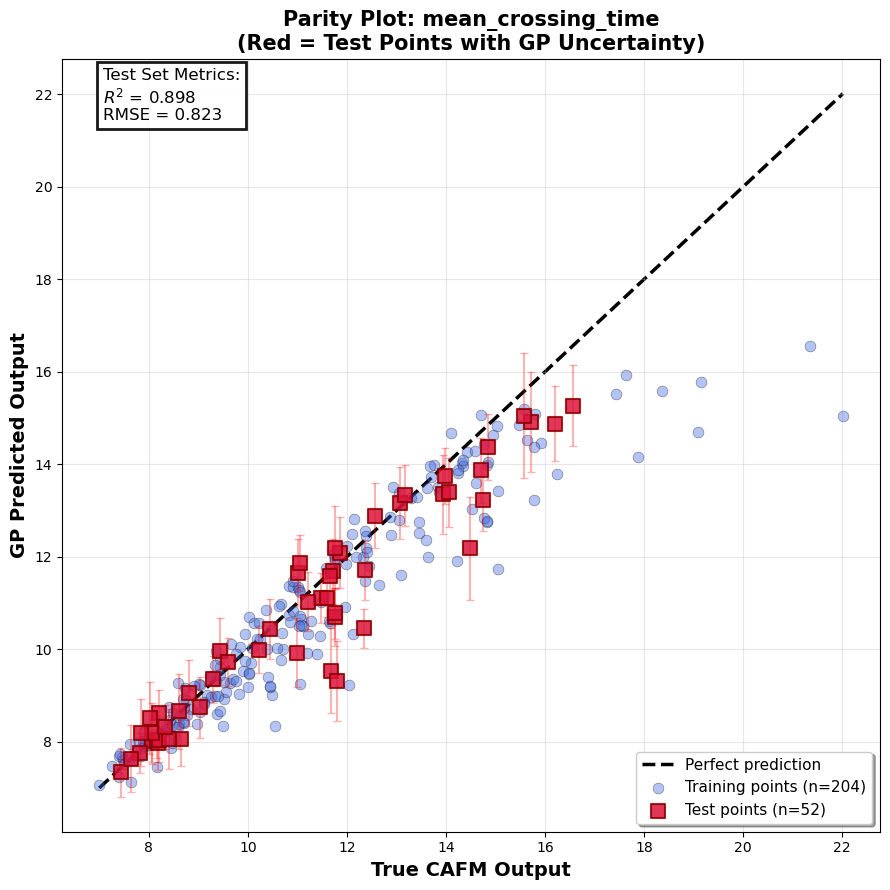

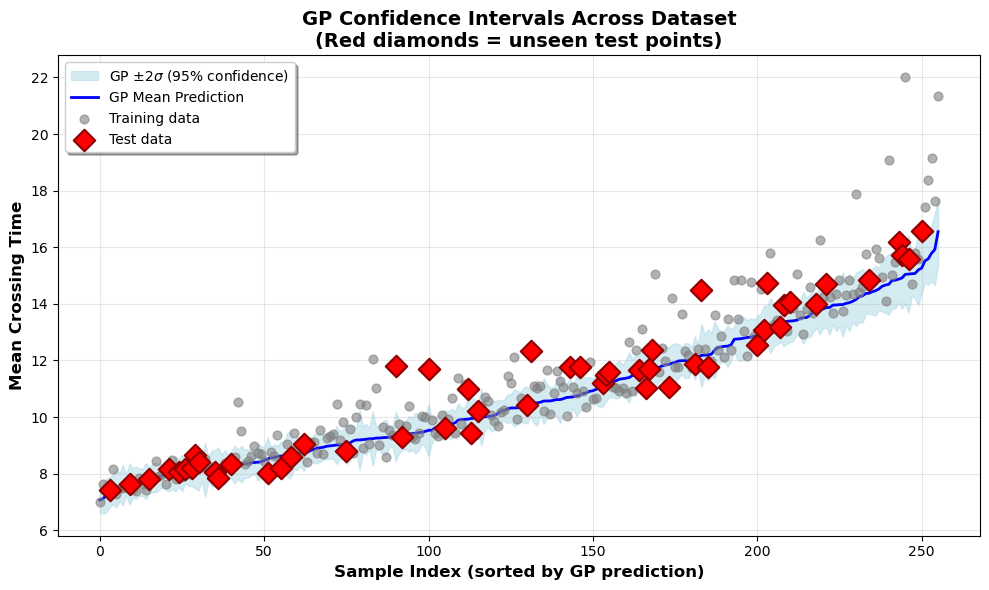


📊 ARD Feature Importance:
------------------------------------------------------------
  v0_mean         | lengthscale =  3.6469 | importance =  0.2742
  flow_ratio      | lengthscale =  7.4295 | importance =  0.1346
  density         | lengthscale =  8.7242 | importance =  0.1146
  R_safety        | lengthscale = 15.0000 | importance =  0.0667
  A               | lengthscale = 15.0000 | importance =  0.0667
  tau             | lengthscale = 15.0000 | importance =  0.0667


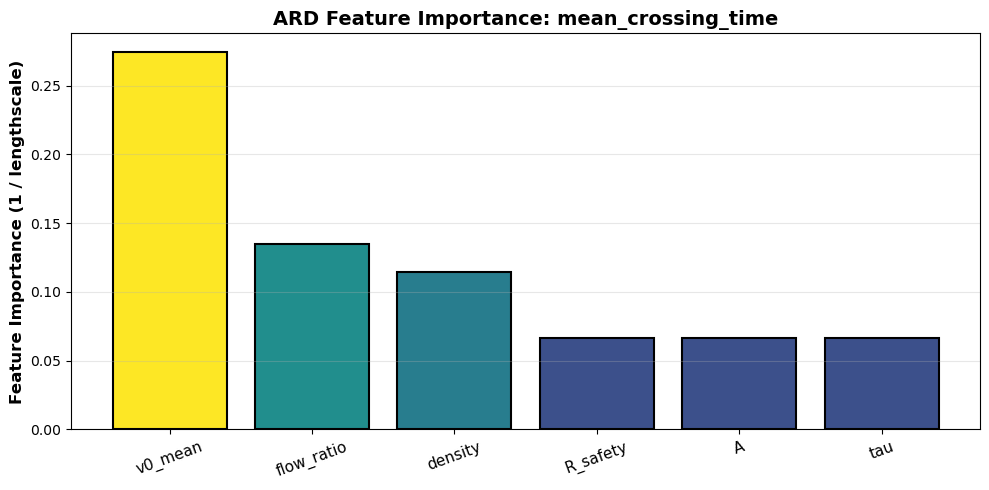

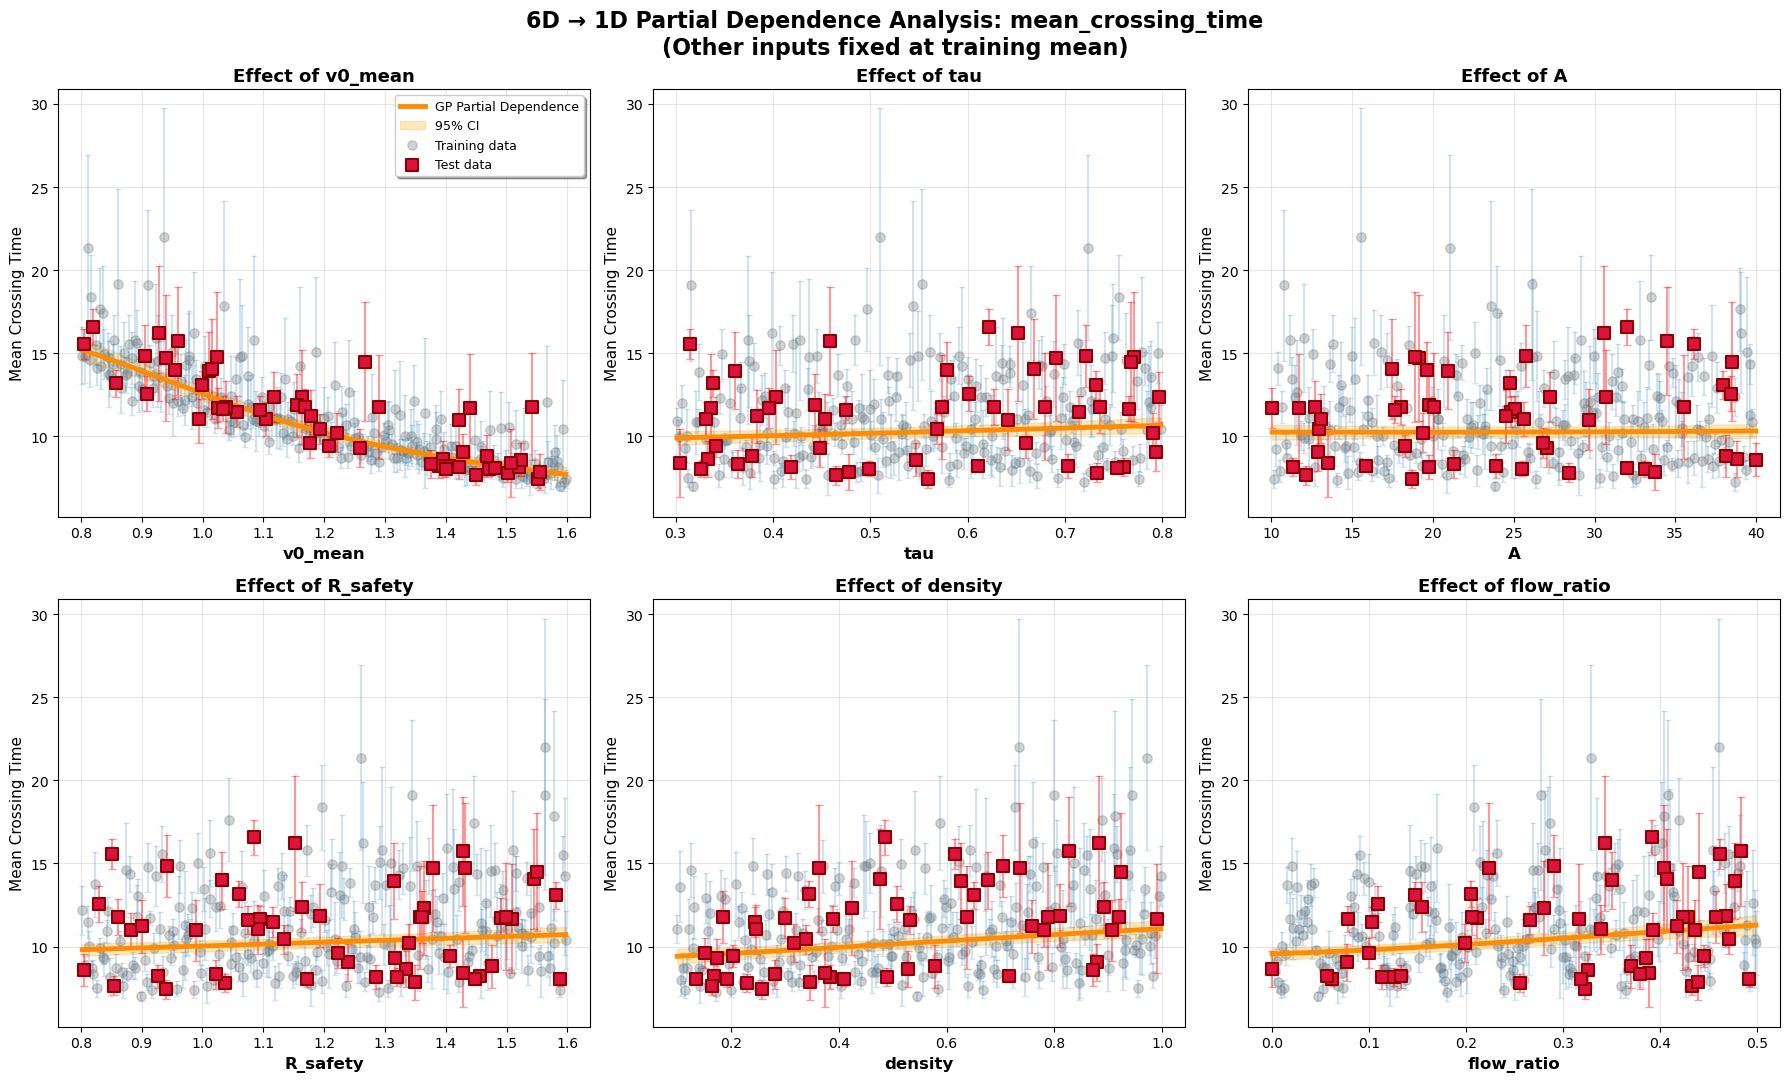

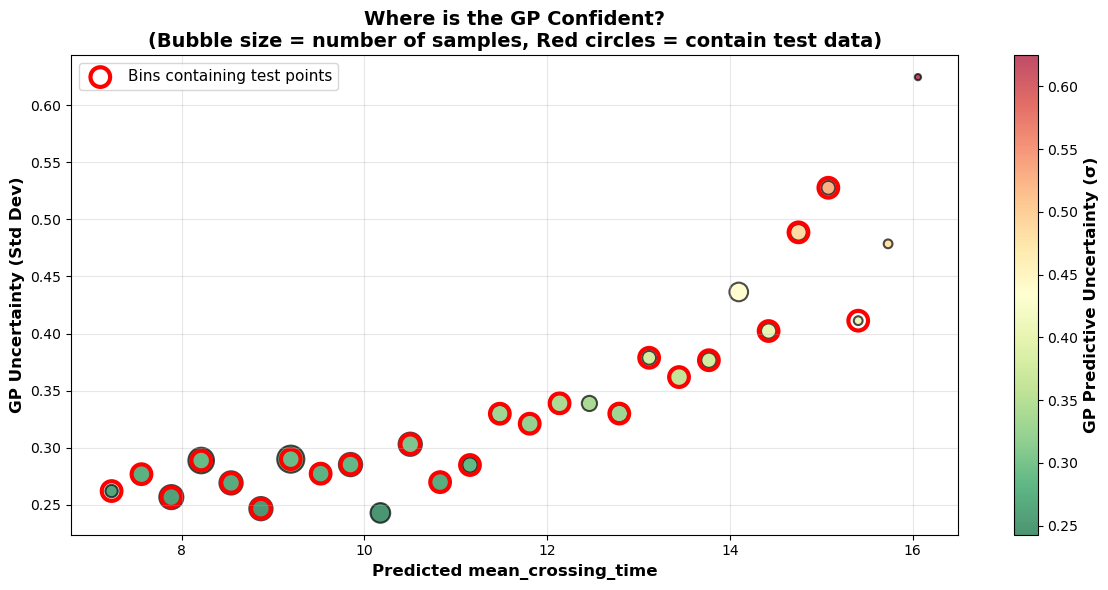

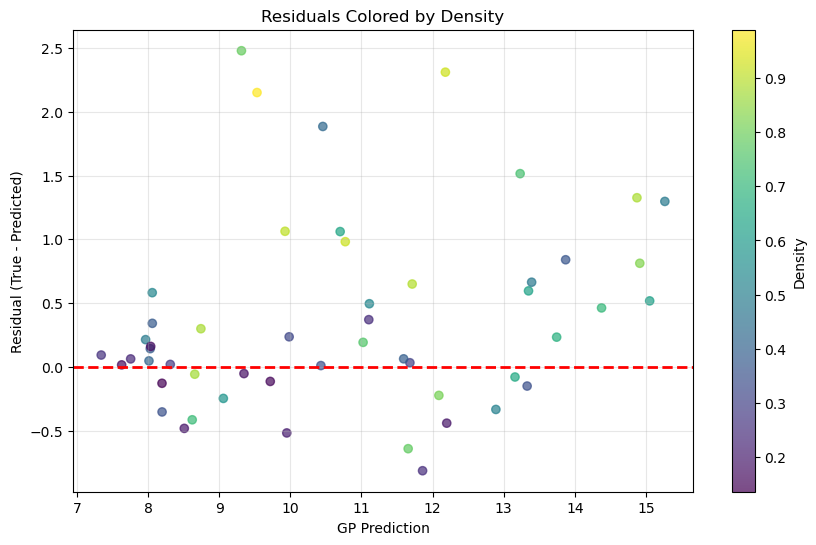


✅ ANALYSIS COMPLETE


In [13]:
if __name__ == "__main__":
    DATA_PATH = r"D:\KIT\social_force_model\cafm_qmc_new_dataset_256x10.npz"

    # ========================================================================
    # 🔧 OPTION 1: Use default lengthscales (let optimizer find them)
    # ========================================================================
    results = run_single_output_gp_sklearn(
        DATA_PATH,
        target_output_idx=0,  # Choose your output
        custom_lengthscales= [0.5, 0.5, 1.0, 0.5, 0.3, 0.5],  # Default: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
        kernel_type="matern",
        nu=2.5,
        n_restarts=10
    )

    # Run analysis
    analyze_single_output_gp_sklearn(results)



## Active Learning


1. LOADING DATA FOR 6D → 1D GP (SKLEARN)
Input parameters: [np.str_('v0_mean'), np.str_('tau'), np.str_('A'), np.str_('R_safety'), np.str_('density'), np.str_('flow_ratio')]

Available outputs:
  0: mean_crossing_time
  1: flow_rate
  2: order_param_mean
  3: mean_speed

✅ Selected target: mean_crossing_time

Dataset shape: X=(256, 6), y=(256,)

Noise variance range (scaled): [0.008070, 7.452604]

2. BUILDING GP KERNEL
Initial lengthscales: [0.5, 0.5, 1.0, 0.5, 0.3, 0.5]

3. TRAINING GP

✅ Training complete!
Final kernel: 1.14**2 * Matern(length_scale=[3.65, 15, 15, 15, 8.72, 7.43], nu=2.5)

📏 LEARNED LENGTHSCALES
  v0_mean         : 3.6469
  tau             : 15.0000
  A               : 15.0000
  R_safety        : 15.0000
  density         : 8.7242
  flow_ratio      : 7.4295

4. PREDICTING ON ENTIRE DATASET

Target output : mean_crossing_time
R² score (test) : 0.8982
RMSE (test)     : 0.8232

5. ENHANCED ANALYSIS


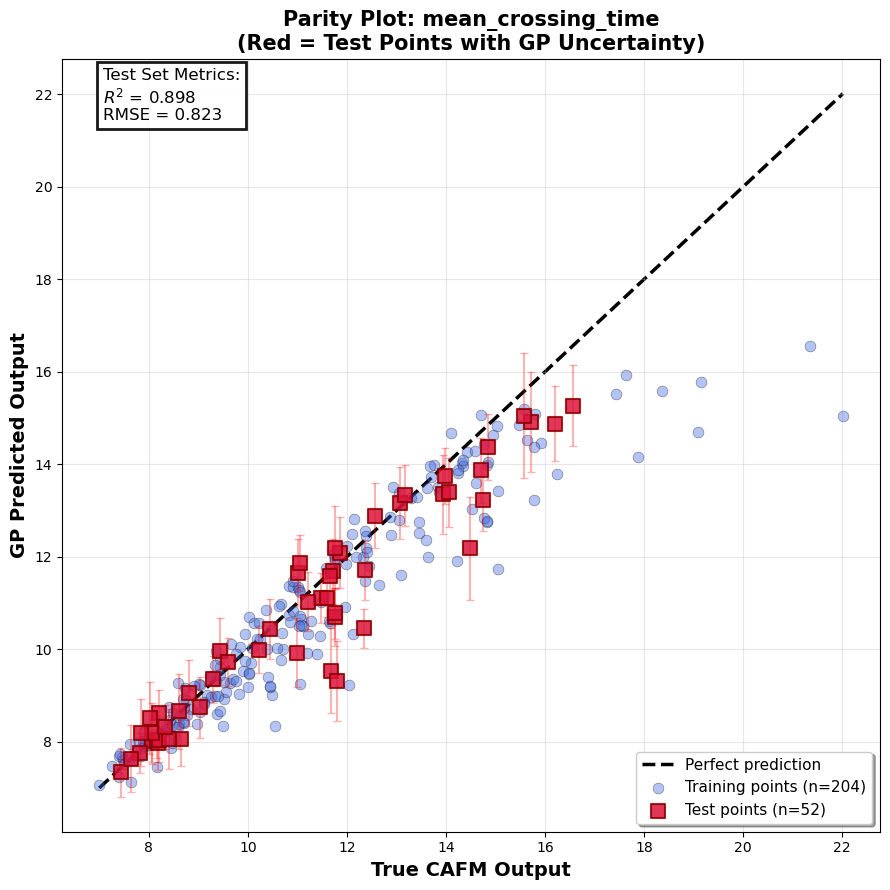

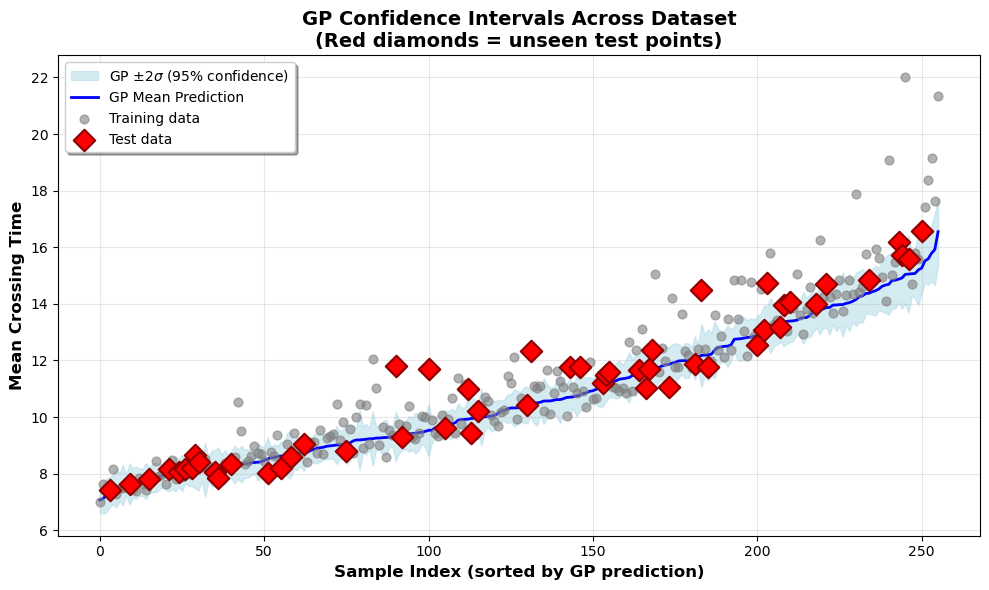


📊 ARD Feature Importance:
------------------------------------------------------------
  v0_mean         | lengthscale =  3.6469 | importance =  0.2742
  flow_ratio      | lengthscale =  7.4295 | importance =  0.1346
  density         | lengthscale =  8.7242 | importance =  0.1146
  R_safety        | lengthscale = 15.0000 | importance =  0.0667
  A               | lengthscale = 15.0000 | importance =  0.0667
  tau             | lengthscale = 15.0000 | importance =  0.0667


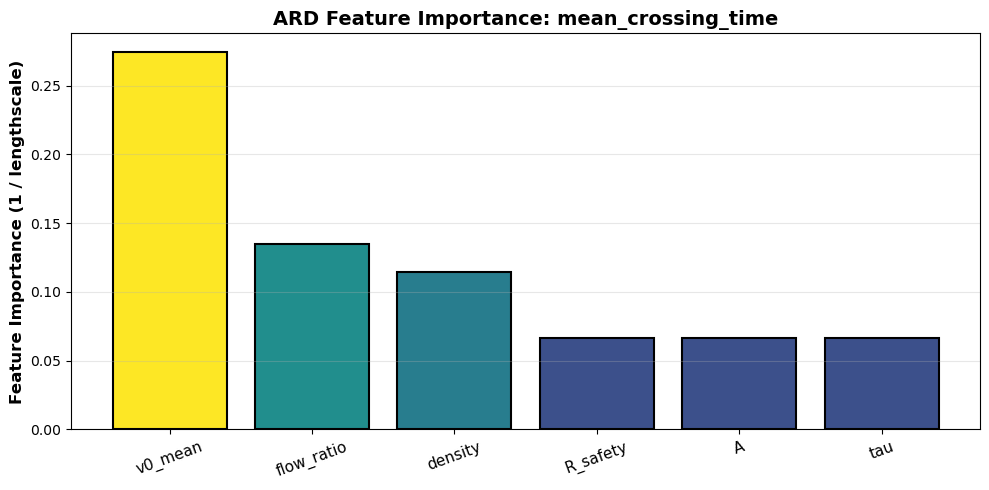

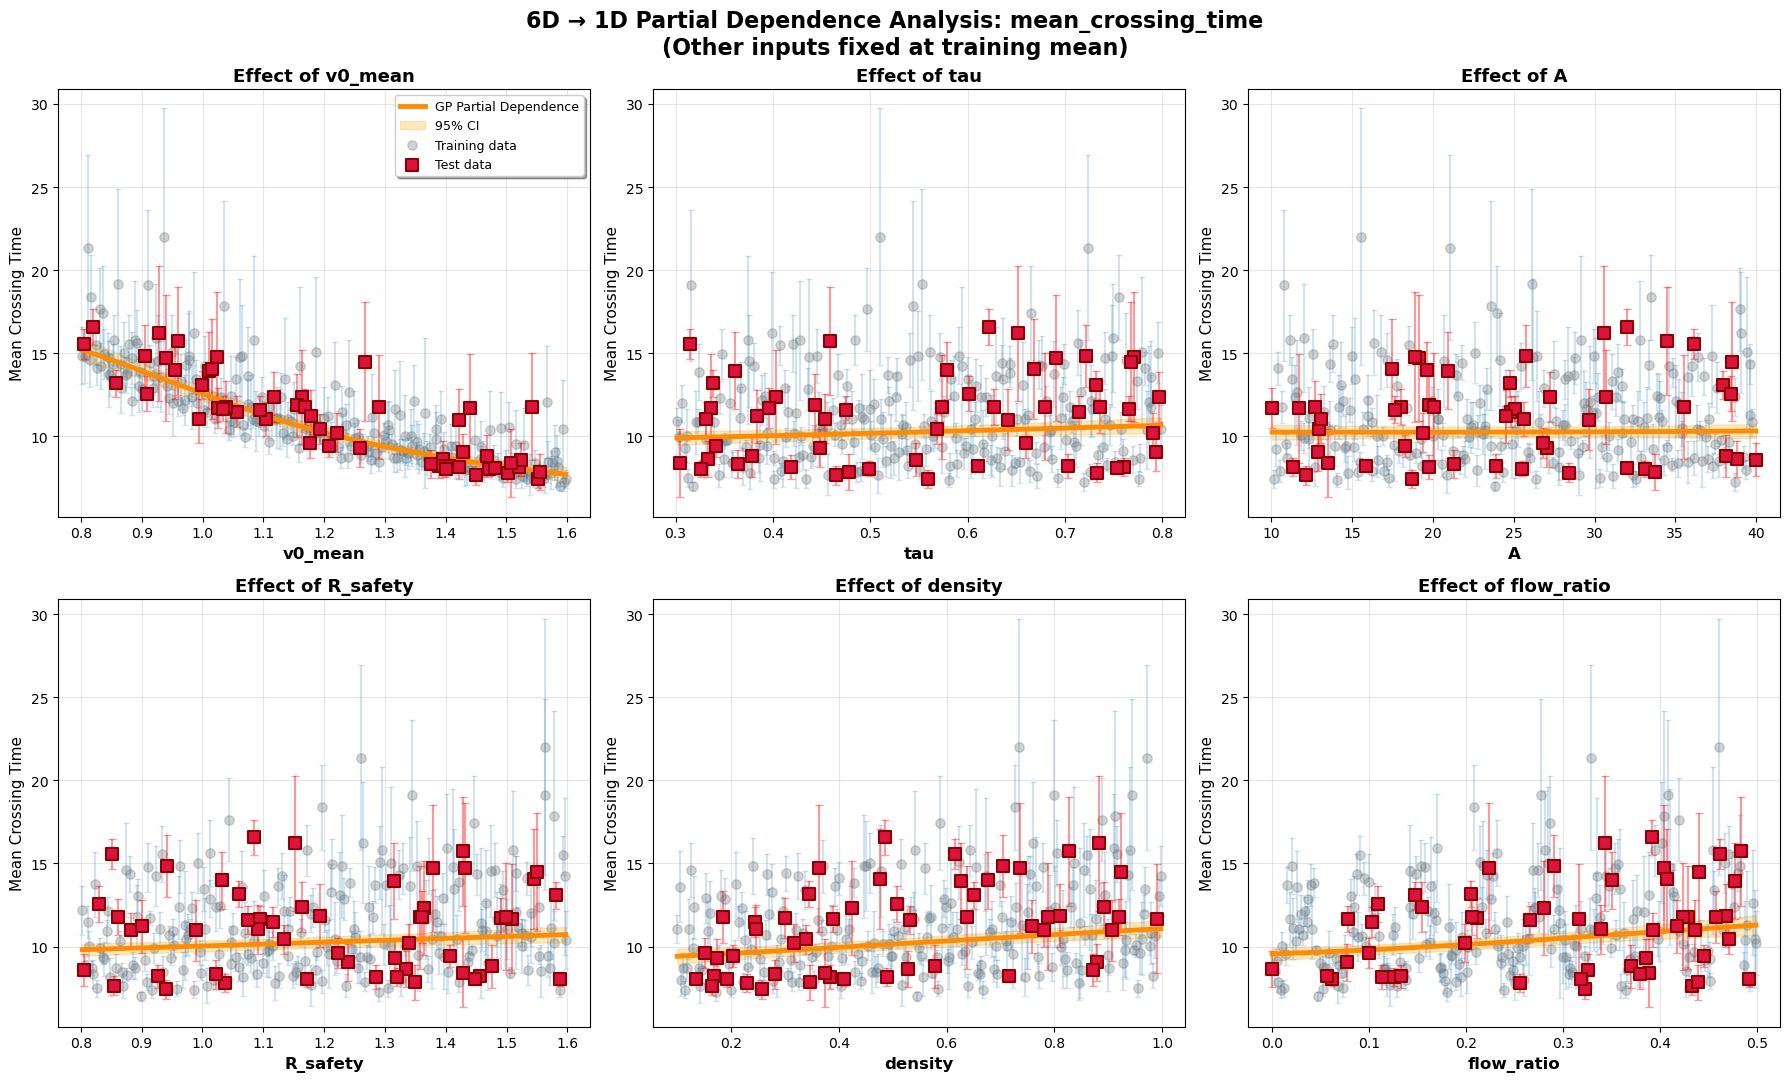

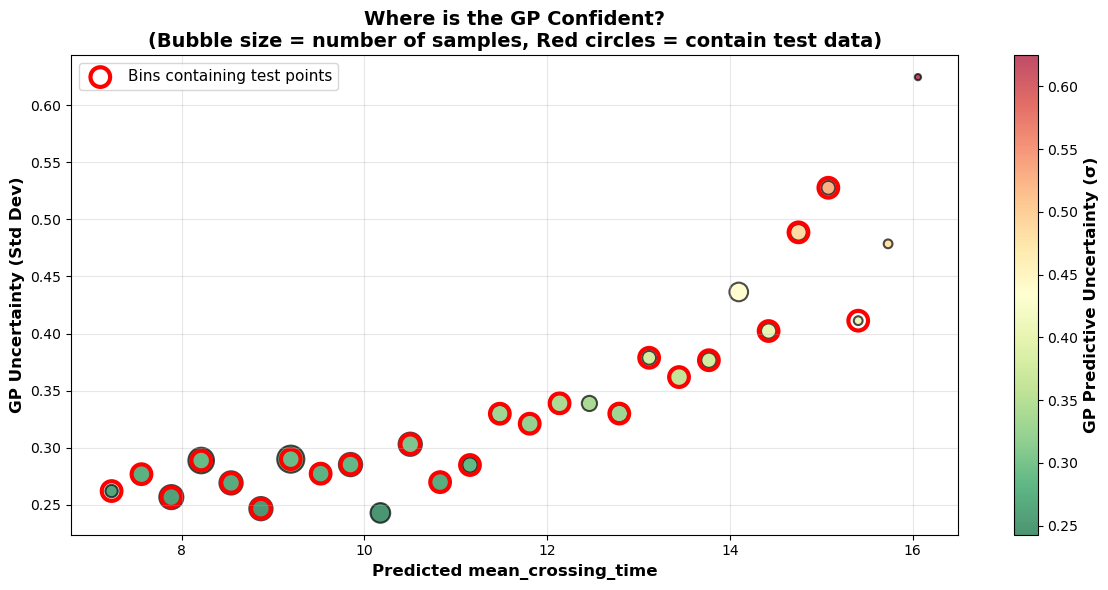

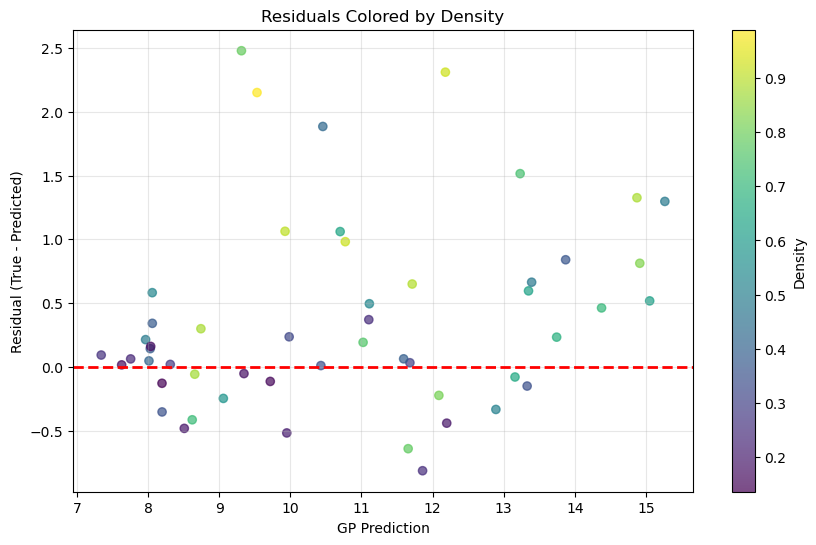


✅ ANALYSIS COMPLETE

STEP 3a — FIND WORST-CASE VARIANCE REGION
Scanning 30,000 candidate points in 6D space...

🎯 WORST-CASE POINT — run your next CAFM simulation here!
------------------------------------------------------------
  v0_mean        : 0.8070
  tau            : 0.3293
  A              : 39.4164
  R_safety       : 1.5742
  density        : 0.9960
  flow_ratio     : 0.4814

  GP std  (real units) : 0.8873
  GP var  (real units) : 0.7873

Top-10 most uncertain points:
  Rank |     Var |    v0_mean |        tau |          A |   R_safety |    density | flow_ratio
  ----------------------------------------------------------------------------------------
     1 |  0.7873 |     0.8070 |     0.3293 |    39.4164 |     1.5742 |     0.9960 |     0.4814
     2 |  0.6169 |     0.8052 |     0.7546 |    16.6787 |     1.4655 |     0.9837 |     0.4746
     3 |  0.6146 |     0.8085 |     0.4442 |    33.7641 |     1.4970 |     0.9913 |     0.4717
     4 |  0.5702 |     0.8223 |     0.3377 | 

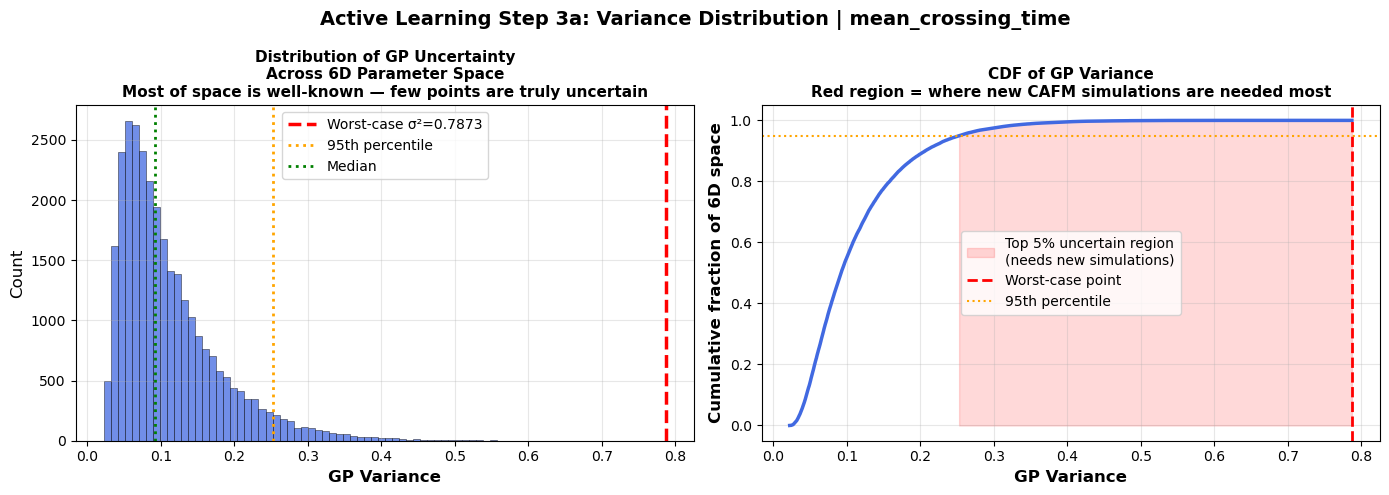

Saved: figE_variance_distribution.png


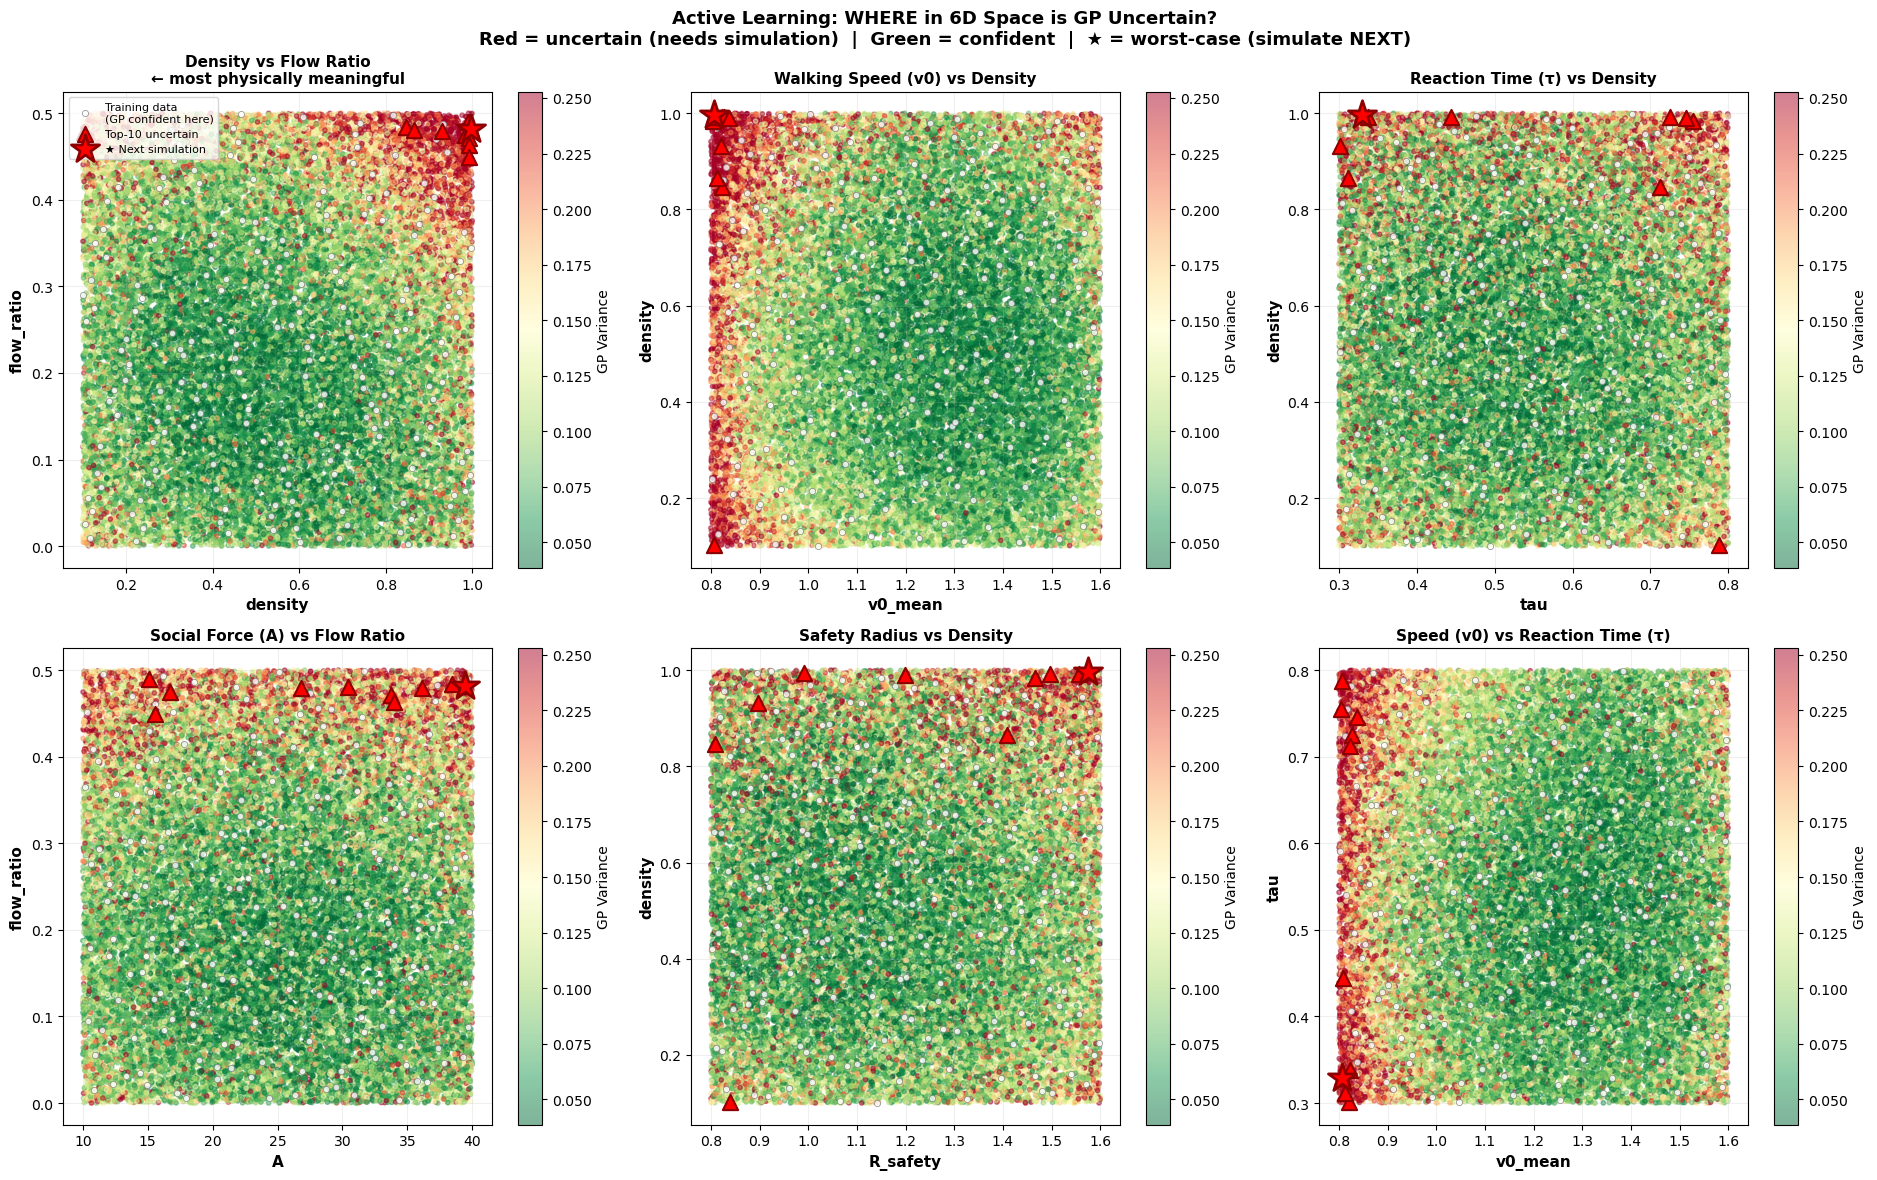

Saved: figF_variance_heatmap.png


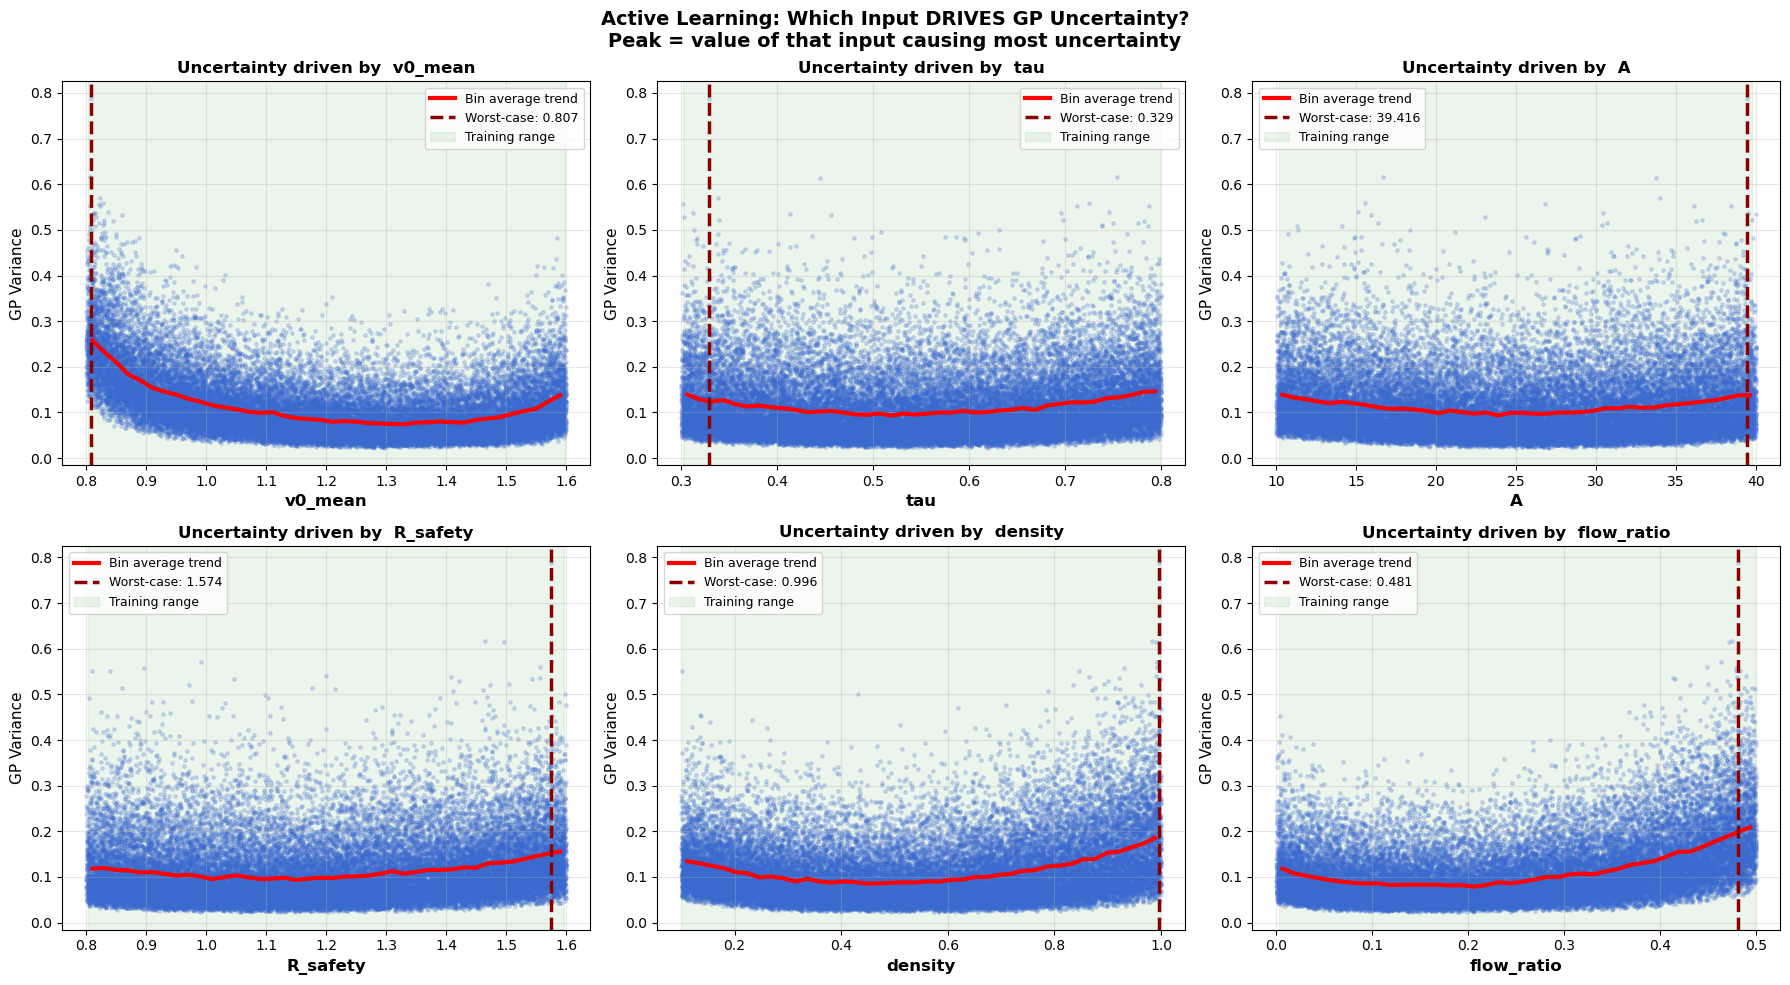

Saved: figG_variance_per_input.png

READY TO RUN REAL CAFM SIMULATIONS!
This will call your actual simulation code from run_batch.py
Each iteration = 10 CAFM simulations

REAL ACTIVE LEARNING WITH CAFM SIMULATIONS
Target: 5 iterations × 10 reps = 50 new simulations

Initial state:
  Training points: 204
  Target output: mean_crossing_time
  Worst-case variance: 0.60268

Starting active learning iterations...

------------------------------------------------------------
ITERATION 1/5
------------------------------------------------------------
  🔍 Finding most uncertain point in 6D parameter space...
  Most uncertain point found:
    v0_mean     : 0.8126
    tau         : 0.4924
    A           : 36.0483
    R_safety    : 1.3840
    density     : 0.9975
    flow_ratio  : 0.4815
  GP uncertainty at this point: 0.60268

  🚀 Running REAL CAFM simulation...
    Running CAFM simulation (10 reps)...
    Parameters: density=0.998, flow_ratio=0.482, v0_mean=0.813
    → 16 major + 14 minor = 30 

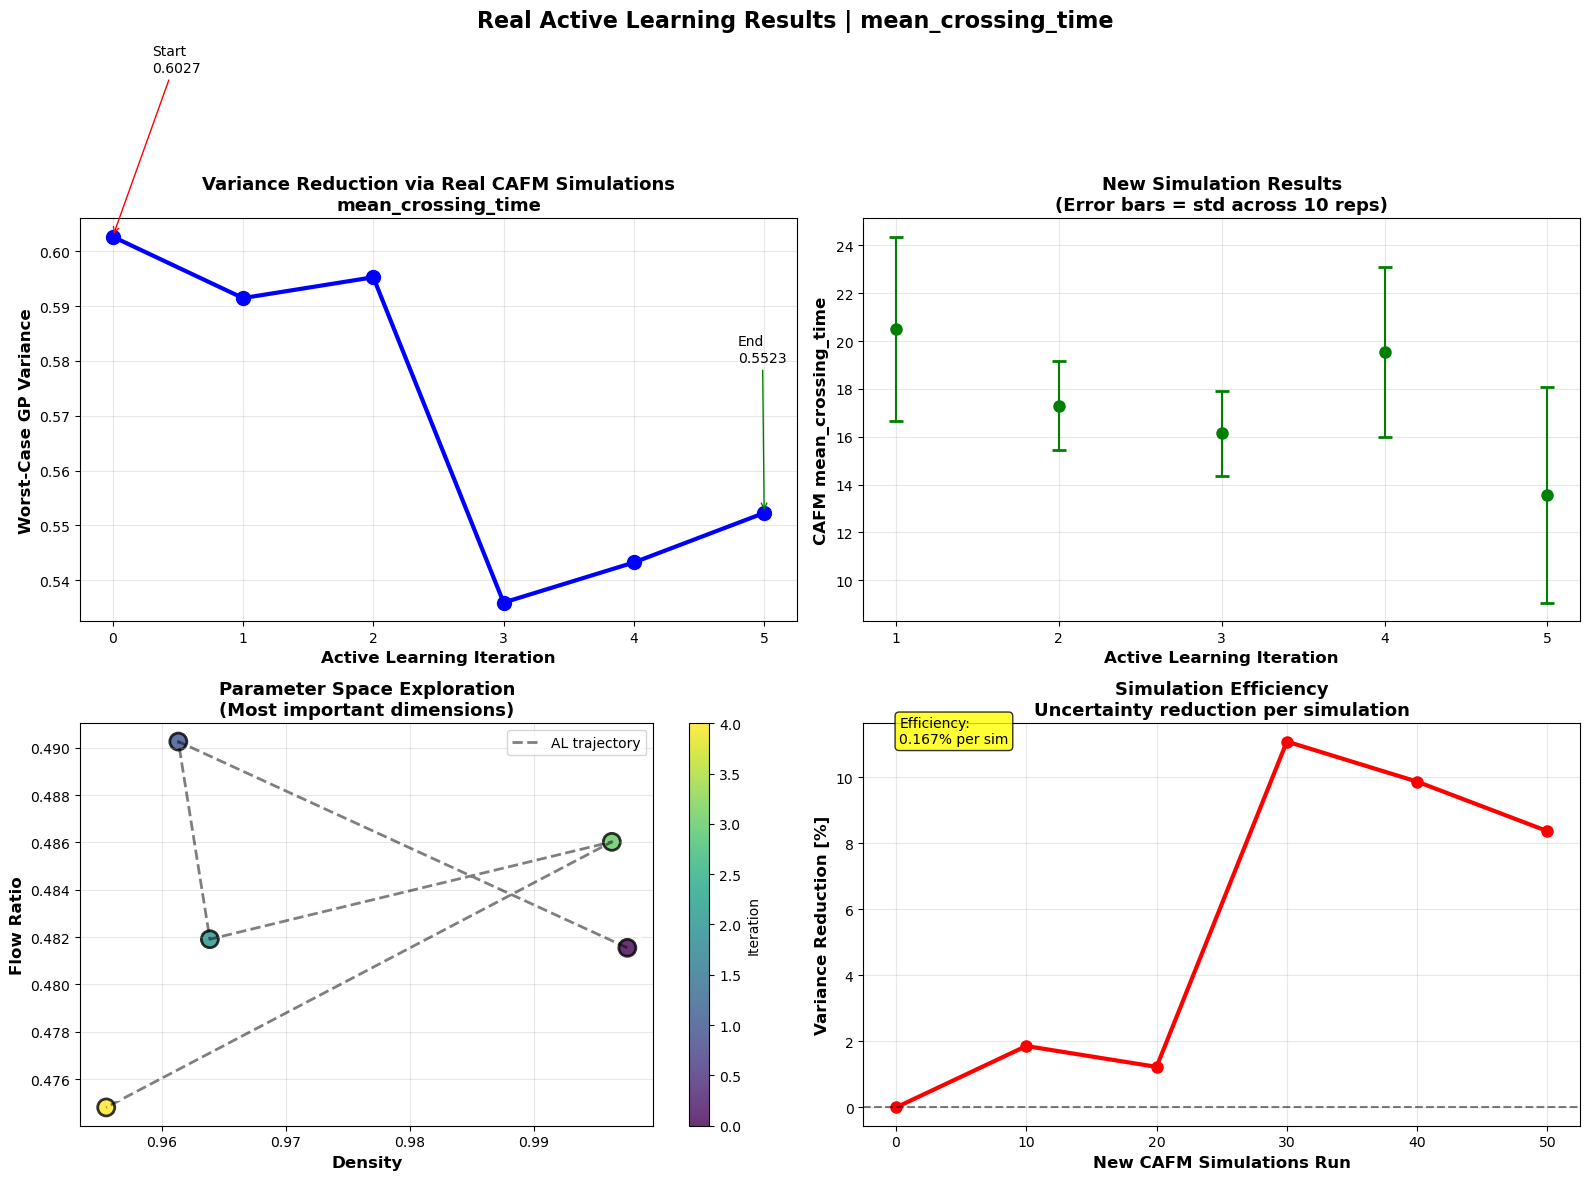

Saved: real_active_learning_results_mean_crossing_time.png

 Active learning complete!
Your GP model now has 209 training points
and is 8.4% more confident!


In [14]:
# ═══════════════════════════════════════════════════════════
# REAL ACTIVE LEARNING — replaces fake version
# Integrates with your existing GP fitting and CAFM simulation
# ═══════════════════════════════════════════════════════════

import sys
import os
sys.path.append(r"D:\KIT\social_force_model")

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel as C

# Import your simulation functions
from run_batch import single_run, density_to_counts

PARAM_NAMES = ["v0_mean", "tau", "A", "R_safety", "density", "flow_ratio"]
OUTPUT_NAMES = ['mean_crossing_time', 'flow_rate', 'order_param_mean', 'mean_speed']
PARAM_BOUNDS = {
    "v0_mean":    (0.80, 1.60),
    "tau":        (0.30, 0.80),
    "A":          (10.0, 40.0),
    "R_safety":   (0.80, 1.60),
    "density":    (0.10, 1.00),
    "flow_ratio": (0.00, 0.50),
}

def find_worst_case_variance(results, n_candidates=30000, seed=42):
    """
    Step 3a: Scan 6D space, find point with MAXIMUM GP variance.
    This identifies the GP region with largest variance.
    """
    gp = results["model"]
    scaler_X = results["scaler_X"]
    scaler_y = results["scaler_y"]
    X_train = results["X_train"]

    print("\n" + "=" * 70)
    print("STEP 3a — FIND WORST-CASE VARIANCE REGION")
    print("=" * 70)
    print(f"Scanning {n_candidates:,} candidate points in 6D space...")

    lowers = np.array([PARAM_BOUNDS[n][0] for n in PARAM_NAMES])
    uppers = np.array([PARAM_BOUNDS[n][1] for n in PARAM_NAMES])

    # Latin Hypercube gives better 6D coverage than pure random
    sampler = qmc.LatinHypercube(d=6, seed=seed)
    cand_raw = qmc.scale(sampler.random(n_candidates), lowers, uppers)

    # Ask GP for variance at every candidate
    _, std_s = gp.predict(scaler_X.transform(cand_raw), return_std=True)
    var_real = (std_s * scaler_y.scale_[0]) ** 2
    std_real = std_s * scaler_y.scale_[0]

    # Find maximum
    worst_idx = int(np.argmax(var_real))
    worst_point = cand_raw[worst_idx]
    worst_var = float(var_real[worst_idx])
    worst_std = float(std_real[worst_idx])

    top10_idx = np.argsort(var_real)[::-1][:10]

    # Print summary
    print(f"\n🎯 WORST-CASE POINT — run your next CAFM simulation here!")
    print("-" * 60)
    for n, v in zip(PARAM_NAMES, worst_point):
        print(f"  {n:<15}: {v:.4f}")
    print(f"\n  GP std  (real units) : {worst_std:.4f}")
    print(f"  GP var  (real units) : {worst_var:.4f}")

    print(f"\nTop-10 most uncertain points:")
    hdr = " | ".join([f"{n:>10}" for n in PARAM_NAMES])
    print(f"  {'Rank':>4} | {'Var':>7} | {hdr}")
    print("  " + "-" * 88)
    for rank, idx in enumerate(top10_idx):
        row = " | ".join([f"{cand_raw[idx, j]:>10.4f}" for j in range(6)])
        print(f"  {rank+1:>4} | {var_real[idx]:>7.4f} | {row}")

    return {
        "worst_point": worst_point,
        "worst_var": worst_var,
        "worst_std": worst_std,
        "candidates": cand_raw,
        "variances": var_real,
        "stds": std_real,
        "top10_points": cand_raw[top10_idx],
        "top10_vars": var_real[top10_idx],
        "X_train": X_train,
    }

def plot_variance_landscape(vr, results):
    """
    Step 3b: 3 figures showing WHERE and WHY the GP is uncertain.

    Figure E — variance histogram + CDF
    Figure F — 2D variance heatmaps for 6 parameter pairs
    Figure G — variance vs each individual input
    """
    target_name = results["target_name"]
    X_train = results["X_train"]
    cands = vr["candidates"]
    variances = vr["variances"]
    wp = vr["worst_point"]
    top10 = vr["top10_points"]

    vmin = np.percentile(variances, 5)
    vmax = np.percentile(variances, 95)

    # ──────────────────────────────────────────────────────
    # FIGURE E: Variance Histogram + CDF
    # ──────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # E1: Histogram
    ax = axes[0]
    ax.hist(variances, bins=80, color="royalblue",
            edgecolor="k", alpha=0.75, linewidth=0.4)
    ax.axvline(
        vr["worst_var"], color="red", lw=2.5, ls="--",
        label=f"Worst-case σ²={vr['worst_var']:.4f}"
    )
    ax.axvline(
        np.percentile(variances, 95), color="orange",
        lw=2, ls=":", label="95th percentile"
    )
    ax.axvline(
        np.percentile(variances, 50), color="green",
        lw=2, ls=":", label="Median"
    )
    ax.set_xlabel("GP Variance", fontsize=12, fontweight="bold")
    ax.set_ylabel("Count", fontsize=12)
    ax.set_title(
        "Distribution of GP Uncertainty\nAcross 6D Parameter Space\n"
        "Most of space is well-known — few points are truly uncertain",
        fontsize=11, fontweight="bold"
    )
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # E2: CDF
    ax = axes[1]
    sv = np.sort(variances)
    cdf = np.arange(len(sv)) / len(sv)
    ax.plot(sv, cdf, color="royalblue", lw=2.5)
    ax.fill_between(
        sv, 0, cdf,
        where=sv >= np.percentile(sv, 95),
        color="red", alpha=0.15,
        label="Top 5% uncertain region\n(needs new simulations)"
    )
    ax.axvline(vr["worst_var"], color="red",
               lw=2, ls="--", label="Worst-case point")
    ax.axhline(0.95, color="orange",
               lw=1.5, ls=":", label="95th percentile")
    ax.set_xlabel("GP Variance", fontsize=12, fontweight="bold")
    ax.set_ylabel("Cumulative fraction of 6D space",
                  fontsize=12, fontweight="bold")
    ax.set_title(
        "CDF of GP Variance\n"
        "Red region = where new CAFM simulations are needed most",
        fontsize=11, fontweight="bold"
    )
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.suptitle(
        f"Active Learning Step 3a: Variance Distribution | {target_name}",
        fontsize=14, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(f"figE_variance_distribution_{target_name}.png", dpi=300)
    plt.show()
    print("Saved: figE_variance_distribution.png")

    # ──────────────────────────────────────────────────────
    # FIGURE F: 2D Variance Heatmaps
    # ──────────────────────────────────────────────────────
    pairs = [
        (4, 5, "Density vs Flow Ratio\n← most physically meaningful"),
        (0, 4, "Walking Speed (v0) vs Density"),
        (1, 4, "Reaction Time (τ) vs Density"),
        (2, 5, "Social Force (A) vs Flow Ratio"),
        (3, 4, "Safety Radius vs Density"),
        (0, 1, "Speed (v0) vs Reaction Time (τ)"),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(19, 12))
    axes = axes.flatten()

    for pidx, (dx, dy, title) in enumerate(pairs):
        ax = axes[pidx]

        # Colour-coded variance cloud
        sc = ax.scatter(
            cands[:, dx], cands[:, dy],
            c=variances, cmap="RdYlGn_r",
            alpha=0.5, s=10,
            vmin=vmin, vmax=vmax
        )
        plt.colorbar(sc, ax=ax, label="GP Variance")

        # White dots = training data = regions GP knows well
        ax.scatter(
            X_train[:, dx], X_train[:, dy],
            color="white", s=20, alpha=0.8,
            edgecolor="gray", lw=0.6, zorder=4,
            label="Training data\n(GP confident here)"
        )

        # Red triangles = top-10 uncertain
        ax.scatter(
            top10[:, dx], top10[:, dy],
            color="red", s=120, marker="^",
            edgecolor="darkred", lw=1.5, zorder=5,
            label="Top-10 uncertain"
        )

        # Red star = THE worst-case point
        ax.scatter(
            wp[dx], wp[dy],
            color="red", s=450, marker="*",
            edgecolor="darkred", lw=2, zorder=6,
            label="★ Next simulation"
        )

        ax.set_xlabel(PARAM_NAMES[dx], fontsize=11, fontweight="bold")
        ax.set_ylabel(PARAM_NAMES[dy], fontsize=11, fontweight="bold")
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.grid(True, alpha=0.2)
        if pidx == 0:
            ax.legend(fontsize=8, loc="best")

    plt.suptitle(
        "Active Learning: WHERE in 6D Space is GP Uncertain?\n"
        "Red = uncertain (needs simulation)  |  "
        "Green = confident  |  ★ = worst-case (simulate NEXT)",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(f"figF_variance_heatmap_{target_name}.png", dpi=300)
    plt.show()
    print("Saved: figF_variance_heatmap.png")

    # ──────────────────────────────────────────────────────
    # FIGURE G: Variance vs Each Input
    # ──────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for dim in range(6):
        ax = axes[dim]

        # Raw scatter
        ax.scatter(cands[:, dim], variances,
                   alpha=0.2, s=6, color="royalblue")

        # Bin average trend line
        sidx = np.argsort(cands[:, dim])
        xs = cands[sidx, dim]
        vs = variances[sidx]
        n_bin = 40
        bx, bv = [], []
        for b in range(n_bin):
            s = int(b * len(xs) / n_bin)
            e = int((b + 1) * len(xs) / n_bin)
            bx.append(xs[s:e].mean())
            bv.append(vs[s:e].mean())
        ax.plot(bx, bv, color="red", lw=3, label="Bin average trend")

        # Worst-case value for this dimension
        ax.axvline(
            wp[dim], color="darkred", lw=2.5, ls="--",
            label=f"Worst-case: {wp[dim]:.3f}"
        )

        # Training data range (shaded green)
        ax.axvspan(
            X_train[:, dim].min(), X_train[:, dim].max(),
            alpha=0.08, color="green",
            label="Training range"
        )

        ax.set_xlabel(PARAM_NAMES[dim], fontsize=12, fontweight="bold")
        ax.set_ylabel("GP Variance", fontsize=11)
        ax.set_title(
            f"Uncertainty driven by  {PARAM_NAMES[dim]}",
            fontsize=12, fontweight="bold"
        )
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.suptitle(
        "Active Learning: Which Input DRIVES GP Uncertainty?\n"
        "Peak = value of that input causing most uncertainty",
        fontsize=14, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(f"figG_variance_per_input_{target_name}.png", dpi=300)
    plt.show()
    print("Saved: figG_variance_per_input.png")

def run_real_active_learning(results, n_iterations=8, n_candidates=10000, n_reps=10):
    """
    REAL Active Learning: Actually runs CAFM simulations at uncertain points.
    Replaces the fake run_active_learning_comparison() function.
    
    Args:
        results: Dict from your run_single_output_gp_sklearn() function
        n_iterations: Number of active learning iterations
        n_candidates: Number of candidate points to search for max variance
        n_reps: Number of CAFM simulation repetitions per point
    
    Returns:
        Dict with results including final GP, variance reduction, etc.
    """
    
    print("\n" + "=" * 70)
    print("REAL ACTIVE LEARNING WITH CAFM SIMULATIONS")
    print("=" * 70)
    print(f"Target: {n_iterations} iterations × {n_reps} reps = {n_iterations * n_reps} new simulations")
    
    # Unpack from your existing GP results dict
    gp = results["model"]
    scaler_X = results["scaler_X"]
    scaler_y = results["scaler_y"]
    X_tr = results["X_train"].copy()
    y_tr = results["y_train"].copy()
    ys_tr = results["y_std_full"][~results["is_test"]].copy()
    target_idx = results["target_output_idx"]
    target_name = OUTPUT_NAMES[target_idx]
    
    # Kernel settings from your original function
    init_ls = results.get("custom_lengthscales", [1.0] * 6)
    kernel_type = results.get("kernel_type", "matern")
    nu = results.get("nu", 2.5)
    n_restarts = results.get("n_restarts", 5)
    
    lowers = np.array([PARAM_BOUNDS[n][0] for n in PARAM_NAMES])
    uppers = np.array([PARAM_BOUNDS[n][1] for n in PARAM_NAMES])
    
    def retrain_gp(X, y, ys):
        """Retrain GP with same settings as your original"""
        X_s = scaler_X.transform(X)
        y_s = scaler_y.transform(y.reshape(-1, 1)).ravel()
        alph = np.clip((ys / scaler_y.scale_[0]) ** 2, 1e-6, None)
        
        if kernel_type == "matern":
            bk = Matern(
                length_scale=init_ls,
                length_scale_bounds=[
                    (1e-3, 5), (1e-3, 15), (1e-3, 15),
                    (1e-3, 15), (1e-3, 15), (1e-3, 15)
                ],
                nu=nu
            )
        else:
            bk = RBF(
                length_scale=init_ls,
                length_scale_bounds=[(1e-3, 1e3)] * 6
            )
        
        k = C(1.0, (1e-3, 1e3)) * bk
        gp_new = GaussianProcessRegressor(
            kernel=k,
            alpha=alph,
            n_restarts_optimizer=n_restarts,
            normalize_y=False,
            random_state=42
        )
        gp_new.fit(X_s, y_s)
        return gp_new
    
    def measure_worst_case_variance(gp_current, seed_offset=0):
        """Measure worst-case variance in current GP"""
        samp = qmc.LatinHypercube(d=6, seed=42 + seed_offset)
        cand = qmc.scale(samp.random(n_candidates), lowers, uppers)
        _, s_s = gp_current.predict(scaler_X.transform(cand), return_std=True)
        return float(np.max((s_s * scaler_y.scale_[0]) ** 2))
    
    def run_cafm_at_point(x_raw, base_seed):
        """Run real CAFM simulation at given parameter point"""
        param_dict = {name: float(x_raw[i]) for i, name in enumerate(PARAM_NAMES)}
        
        print(f"    Running CAFM simulation ({n_reps} reps)...")
        print(f"    Parameters: density={param_dict['density']:.3f}, "
              f"flow_ratio={param_dict['flow_ratio']:.3f}, "
              f"v0_mean={param_dict['v0_mean']:.3f}")
        
        # Show pedestrian counts
        n_major, n_minor = density_to_counts(param_dict['density'], param_dict['flow_ratio'])
        print(f"    → {n_major} major + {n_minor} minor = {n_major + n_minor} total pedestrians")
        
        results_list = []
        failed_runs = 0
        
        for rep in range(n_reps):
            try:
                seed = base_seed + rep
                output_vector = single_run(param_dict, seed)
                target_value = output_vector[target_idx]
                results_list.append(target_value)
            except Exception as e:
                failed_runs += 1
                print(f"      Rep {rep+1} failed: {e}")
                results_list.append(np.nan)
        
        # Calculate statistics
        results_array = np.array(results_list, dtype=float)
        mean_value = float(np.nanmean(results_array))
        std_value = float(np.nanstd(results_array))
        
        if failed_runs > 0:
            print(f"    Warning: {failed_runs}/{n_reps} runs failed")
        
        print(f"    Results: mean={mean_value:.3f}, std={std_value:.3f}")
        return mean_value, std_value
    
    # Track progress
    wc_variances = [measure_worst_case_variance(gp)]
    sim_count = len(X_tr) * 10  # Original dataset was 10 reps per point
    
    print(f"\nInitial state:")
    print(f"  Training points: {len(X_tr)}")
    print(f"  Target output: {target_name}")
    print(f"  Worst-case variance: {wc_variances[0]:.5f}")
    print(f"\nStarting active learning iterations...")
    
    # Current training data
    X_current = X_tr.copy()
    y_current = y_tr.copy()
    ys_current = ys_tr.copy()
    gp_current = gp
    
    # Store iteration details
    iteration_details = []
    
    for iteration in range(n_iterations):
        print(f"\n" + "-" * 60)
        print(f"ITERATION {iteration + 1}/{n_iterations}")
        print("-" * 60)
        
        # Step 1: Find most uncertain point
        print("  🔍 Finding most uncertain point in 6D parameter space...")
        samp = qmc.LatinHypercube(d=6, seed=42 + iteration)
        candidates = qmc.scale(samp.random(n_candidates), lowers, uppers)
        _, std_s = gp_current.predict(scaler_X.transform(candidates), return_std=True)
        var_candidates = (std_s * scaler_y.scale_[0]) ** 2
        
        worst_idx = np.argmax(var_candidates)
        x_new_raw = candidates[worst_idx]
        uncertainty_before = float(var_candidates[worst_idx])
        
        param_dict = {name: float(x_new_raw[i]) for i, name in enumerate(PARAM_NAMES)}
        
        print(f"  Most uncertain point found:")
        for name, val in param_dict.items():
            print(f"    {name:<12}: {val:.4f}")
        print(f"  GP uncertainty at this point: {uncertainty_before:.5f}")
        
        # Step 2: Run REAL CAFM simulation
        print(f"\n  🚀 Running REAL CAFM simulation...")
        try:
            y_new_mean, y_new_std = run_cafm_at_point(x_new_raw, 1000 + iteration)
            sim_count += n_reps
            
            print(f"  ✅ Simulation successful!")
            print(f"    Mean {target_name}: {y_new_mean:.3f}")
            print(f"    Std  {target_name}: {y_new_std:.3f}")
            
        except Exception as e:
            print(f"  ❌ Simulation failed: {e}")
            print("  Skipping this iteration...")
            continue
        
        # Step 3: Add to training set
        X_current = np.vstack([X_current, x_new_raw.reshape(1, -1)])
        y_current = np.append(y_current, y_new_mean)
        ys_current = np.append(ys_current, y_new_std)
        
        print(f"  📊 Training set updated: {len(X_current)} points")
        
        # Step 4: Retrain GP
        print(f"  🔄 Retraining GP...")
        try:
            gp_current = retrain_gp(X_current, y_current, ys_current)
            print(f"  ✅ GP retrained successfully")
        except Exception as e:
            print(f"  ❌ GP retraining failed: {e}")
            break
        
        # Step 5: Measure new worst-case variance
        new_wc_var = measure_worst_case_variance(gp_current, iteration)
        wc_variances.append(new_wc_var)
        
        reduction = (wc_variances[0] - new_wc_var) / wc_variances[0] * 100
        print(f"  📈 New worst-case variance: {new_wc_var:.5f} ({reduction:.1f}% reduction)")
        
        # Store iteration details
        iteration_details.append({
            "iteration": iteration + 1,
            "params": param_dict.copy(),
            "uncertainty_before": uncertainty_before,
            "sim_mean": y_new_mean,
            "sim_std": y_new_std,
            "wc_variance_after": new_wc_var,
            "reduction_pct": reduction
        })
    
    # Final summary
    print(f"\n" + "=" * 70)
    print("🎉 REAL ACTIVE LEARNING COMPLETED!")
    print("=" * 70)
    print(f"  Target output:           {target_name}")
    print(f"  Initial training points: {len(X_tr)}")
    print(f"  Final training points:   {len(X_current)}")
    print(f"  New simulations run:     {sim_count - len(X_tr) * 10}")
    print(f"  Initial worst-case var:  {wc_variances[0]:.5f}")
    print(f"  Final worst-case var:    {wc_variances[-1]:.5f}")
    final_reduction = (wc_variances[0] - wc_variances[-1]) / wc_variances[0] * 100
    print(f"  Total variance reduction: {final_reduction:.1f}%")
    
    return {
        "X_final": X_current,
        "y_final": y_current,
        "ys_final": ys_current,
        "gp_final": gp_current,
        "wc_variances": wc_variances,
        "sim_count": sim_count,
        "reduction_pct": final_reduction,
        "iteration_details": iteration_details,
        "target_name": target_name
    }

def plot_real_active_learning_results(al_results):
    """
    Visualize the results of real active learning
    """
    wc_vars = al_results["wc_variances"]
    iterations = np.arange(len(wc_vars))
    target_name = al_results["target_name"]
    details = al_results.get("iteration_details", [])
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Top left: Variance reduction over iterations
    ax = axes[0, 0]
    ax.plot(iterations, wc_vars, 'bo-', linewidth=3, markersize=10)
    ax.set_xlabel("Active Learning Iteration", fontsize=12, fontweight="bold")
    ax.set_ylabel("Worst-Case GP Variance", fontsize=12, fontweight="bold")
    ax.set_title(f"Variance Reduction via Real CAFM Simulations\n{target_name}", 
                 fontsize=13, fontweight="bold")
    ax.grid(True, alpha=0.3)
    
    # Annotate start/end
    if len(wc_vars) > 0:
        ax.annotate(f"Start\n{wc_vars[0]:.4f}", 
                    xy=(0, wc_vars[0]), xytext=(0.3, wc_vars[0] * 1.05),
                    arrowprops=dict(arrowstyle='->', color='red'), fontsize=10)
    if len(wc_vars) > 1:
        ax.annotate(f"End\n{wc_vars[-1]:.4f}", 
                    xy=(len(wc_vars)-1, wc_vars[-1]), 
                    xytext=(len(wc_vars)-1.2, wc_vars[-1] * 1.05),
                    arrowprops=dict(arrowstyle='->', color='green'), fontsize=10)
    
    # Top right: Simulation results from each iteration
    ax = axes[0, 1]
    if details:
        sim_means = [d["sim_mean"] for d in details]
        sim_stds = [d["sim_std"] for d in details]
        x_pos = range(1, len(sim_means) + 1)
        
        ax.errorbar(x_pos, sim_means, yerr=sim_stds, 
                   fmt='go', capsize=5, capthick=2, markersize=8)
        ax.set_xlabel("Active Learning Iteration", fontsize=12, fontweight="bold")
        ax.set_ylabel(f"CAFM {target_name}", fontsize=12, fontweight="bold")
        ax.set_title("New Simulation Results\n(Error bars = std across 10 reps)", 
                     fontsize=13, fontweight="bold")
        ax.grid(True, alpha=0.3)
        ax.set_xticks(x_pos)
    
    # Bottom left: Parameter space exploration
    ax = axes[1, 0]
    if details:
        densities = [d["params"]["density"] for d in details]
        flow_ratios = [d["params"]["flow_ratio"] for d in details]
        colors = range(len(densities))
        
        # Plot trajectory
        ax.plot(densities, flow_ratios, 'k--', alpha=0.5, linewidth=2, label='AL trajectory')
        
        scatter = ax.scatter(densities, flow_ratios, c=colors, cmap='viridis', 
                           s=150, alpha=0.8, edgecolors='black', linewidth=2)
        ax.set_xlabel("Density", fontsize=12, fontweight="bold")
        ax.set_ylabel("Flow Ratio", fontsize=12, fontweight="bold")
        ax.set_title("Parameter Space Exploration\n(Most important dimensions)", 
                     fontsize=13, fontweight="bold")
        ax.grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=ax, label="Iteration")
        ax.legend()
        
        # Annotate points
        for i, (d, f) in enumerate(zip(densities, flow_ratios)):
            ax.annotate(f'{i+1}', (d, f), xytext=(5, 5), 
                       textcoords='offset points', fontsize=10, fontweight='bold',
                       color='white')
    
    # Bottom right: Cumulative efficiency
    ax = axes[1, 1]
    reduction_pcts = [(wc_vars[0] - v) / wc_vars[0] * 100 for v in wc_vars]
    cum_sims = [i * 10 for i in iterations]  # 10 reps per iteration
    
    ax.plot(cum_sims, reduction_pcts, 'ro-', linewidth=3, markersize=8)
    ax.set_xlabel("New CAFM Simulations Run", fontsize=12, fontweight="bold")
    ax.set_ylabel("Variance Reduction [%]", fontsize=12, fontweight="bold")
    ax.set_title("Simulation Efficiency\nUncertainty reduction per simulation", 
                 fontsize=13, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    
    # Add efficiency annotation
    if len(cum_sims) > 1:
        final_eff = reduction_pcts[-1] / cum_sims[-1] if cum_sims[-1] > 0 else 0
        ax.text(0.05, 0.95, f"Efficiency:\n{final_eff:.3f}% per sim",
                transform=ax.transAxes, fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.8))
    
    plt.suptitle(f"Real Active Learning Results | {target_name}", 
                 fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"real_active_learning_results_{target_name}.png", 
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: real_active_learning_results_{target_name}.png")

# ═══════════════════════════════════════════════════════════
# Usage with your existing code
# ═══════════════════════════════════════════════════════════
if __name__ == "__main__":
    
    DATA_PATH = r"D:\KIT\social_force_model\cafm_qmc_new_dataset_256x10.npz"
    
    # Your existing GP training
    results = run_single_output_gp_sklearn(
        DATA_PATH,
        target_output_idx=0,  # 0=mean_crossing_time
        custom_lengthscales=[0.5, 0.5, 1.0, 0.5, 0.3, 0.5],
        kernel_type="matern",
        nu=2.5,
        n_restarts=10
    )
    
    # Your existing analysis
    analyze_single_output_gp_sklearn(results)
    
    # Your existing variance finding (keep this)
    vr = find_worst_case_variance(results, n_candidates=30000)
    plot_variance_landscape(vr, results)
    
    # NEW: Real active learning (replaces fake version)
    print("\n" + "=" * 30)
    print("READY TO RUN REAL CAFM SIMULATIONS!")
    print("This will call your actual simulation code from run_batch.py")
    print("Each iteration = 10 CAFM simulations")
    print("=" * 30)
    
    user_input = input("\nProceed with real active learning? (y/N): ")
    if user_input.lower() in ['y', 'yes']:
        
        al_results = run_real_active_learning(
            results, 
            n_iterations=5,      # Start small for testing
            n_candidates=10000,  # Search space size
            n_reps=10           # Same as original dataset
        )
        
        # Visualize results
        plot_real_active_learning_results(al_results)
        
        print(f"\n Active learning complete!")
        print(f"Your GP model now has {len(al_results['X_final'])} training points")
        print(f"and is {al_results['reduction_pct']:.1f}% more confident!")
        
    else:
        print("Active learning cancelled.")